**Dublin Bikes Data Analysis through Visualizations in R**

Data storytelling is a crucial component of data analysis, enabling organizations and city planners to understand patterns in urban mobility. With the help of visualizations, we can uncover insights from complex datasets, such as bike-sharing usage, and make informed decisions to improve transportation planning.

This project focuses on analyzing Dublin Bikes data using R, with a special emphasis on temporal and spatial visualizations. Through heatmaps and plots, we explore bike usage patterns across hours, weekdays, and months, identify peak stations, and understand how cyclists interact with the city’s bike-sharing system.

Goal: To learn and apply data visualization techniques in R (using libraries like ggplot2), while gaining actionable insights from the Dublin Bikes dataset.

### Importing necessary libraries

1. **gplot2**: ggplot2 is the most popular data visualization library that is most widely used for creating aesthetic visualization plots.
2. **lubridate**: Use time-frames in the dataset
3. **dplyr**: Data Manipulation
4. **tidyr**: Tidy the data
5. **DT**: Datatables in JS
6. **scales**: With the help of graphical scales, we can automatically map the data to the correct scales with well-placed axes and legends.

In [1]:
#install.packages(c("tidyverse", "lubridate", "ggthemes", "scales"))

In [2]:
library(tidyverse)
library(lubridate)
library(ggthemes)
library(scales)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




In [3]:

meta_file <- "/kaggle/input/dublin-bike-data/archive/dublin.csv"
stations <- read_csv(meta_file)

library(purrr)

data_files <- c(
  "/kaggle/input/dublin-bike-data/archive/dublinbike-historical-data-2022-01.csv",
  "/kaggle/input/dublin-bike-data/archive/dublinbike-historical-data-2022-02.csv",
  "/kaggle/input/dublin-bike-data/archive/dublinbike-historical-data-2022-03.csv",
  "/kaggle/input/dublin-bike-data/archive/dublinbike-historical-data-2022-04.csv"
)

bikes <- data_files %>%
  map_df(~ read_csv(.x, show_col_types = FALSE))  # combines all 4 months


Rows: 110 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Name, Address
dbl (3): Number, Latitude, Longitude

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
summary(bikes)
nrow(bikes)


   STATION ID          TIME                       
 Min.   :  1.00   Min.   :2022-01-01 00:00:04.00  
 1st Qu.: 31.00   1st Qu.:2022-01-30 22:30:02.00  
 Median : 61.00   Median :2022-03-01 23:30:02.00  
 Mean   : 60.98   Mean   :2022-03-01 23:01:22.23  
 3rd Qu.: 90.00   3rd Qu.:2022-04-01 00:00:02.00  
 Max.   :507.00   Max.   :2022-04-30 23:30:02.00  
  LAST UPDATED                        NAME            BIKE_STANDS
 Min.   :2021-11-18 07:11:16.00   Length:633460      Min.   : 1  
 1st Qu.:2022-01-30 22:25:03.75   Class :character   1st Qu.:29  
 Median :2022-03-01 23:20:23.00   Mode  :character   Median :30  
 Mean   :2022-03-01 22:18:25.36                      Mean   :32  
 3rd Qu.:2022-03-31 23:59:35.50                      3rd Qu.:40  
 Max.   :2022-04-30 23:29:18.00                      Max.   :40  
 AVAILABLE_BIKE_STANDS AVAILABLE_BIKES    STATUS            ADDRESS         
 Min.   : 0.00         Min.   : 0.00   Length:633460      Length:633460     
 1st Qu.:11.00         1st 

[1] 633460

Feature Extraction

In [5]:
bikes <- bikes %>%
  mutate(
    datetime = TIME,  # already POSIXct
    hour = hour(datetime),
    weekday = wday(datetime, label = TRUE),  # Mon, Tue...
    month = month(datetime, label = TRUE),   # Jan, Feb...
    year = year(datetime)
  ) %>%
  distinct() %>%   # remove exact duplicate rows
  drop_na()        # remove rows with missing essential info


In [6]:
# Check structure
glimpse(bikes)

# Check number of unique stations
length(unique(bikes$`STATION ID`))

# Quick summary by month
bikes %>%
  group_by(month) %>%
  summarise(avg_bikes = mean(AVAILABLE_BIKES))


Rows: 633,460
Columns: 16
$ `STATION ID`          <dbl> 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, …
$ TIME                  <dttm> 2022-01-01 00:00:04, 2022-01-01 00:00:04, 2022-…
$ `LAST UPDATED`        <dttm> 2021-12-31 23:57:39, 2021-12-31 23:49:57, 2021-…
$ NAME                  <chr> "BLESSINGTON STREET", "BOLTON STREET", "GREEK ST…
$ BIKE_STANDS           <dbl> 20, 20, 20, 40, 20, 29, 30, 24, 16, 30, 20, 30, …
$ AVAILABLE_BIKE_STANDS <dbl> 10, 19, 9, 17, 13, 4, 26, 21, 4, 18, 2, 21, 11, …
$ AVAILABLE_BIKES       <dbl> 10, 1, 11, 23, 7, 25, 4, 3, 12, 12, 18, 9, 5, 11…
$ STATUS                <chr> "OPEN", "OPEN", "OPEN", "OPEN", "OPEN", "OPEN", …
$ ADDRESS               <chr> "Blessington Street", "Bolton Street", "Greek St…
$ LATITUDE              <dbl> 53.3568, 53.3512, 53.3469, 53.3307, 53.3434, 53.…
$ LONGITUDE             <dbl> -6.26814, -6.26986, -6.27298, -6.26018, -6.27012…
$ datetime              <dttm> 2022-01-01 00:00:04, 2022-01-01 00:00:04, 2022-…
$ hour        

[1] 113

month,avg_bikes
<ord>,<dbl>
Jan,12.74141
Feb,12.76969
Mar,12.64419
Apr,12.59104


Avg Bike per Hour

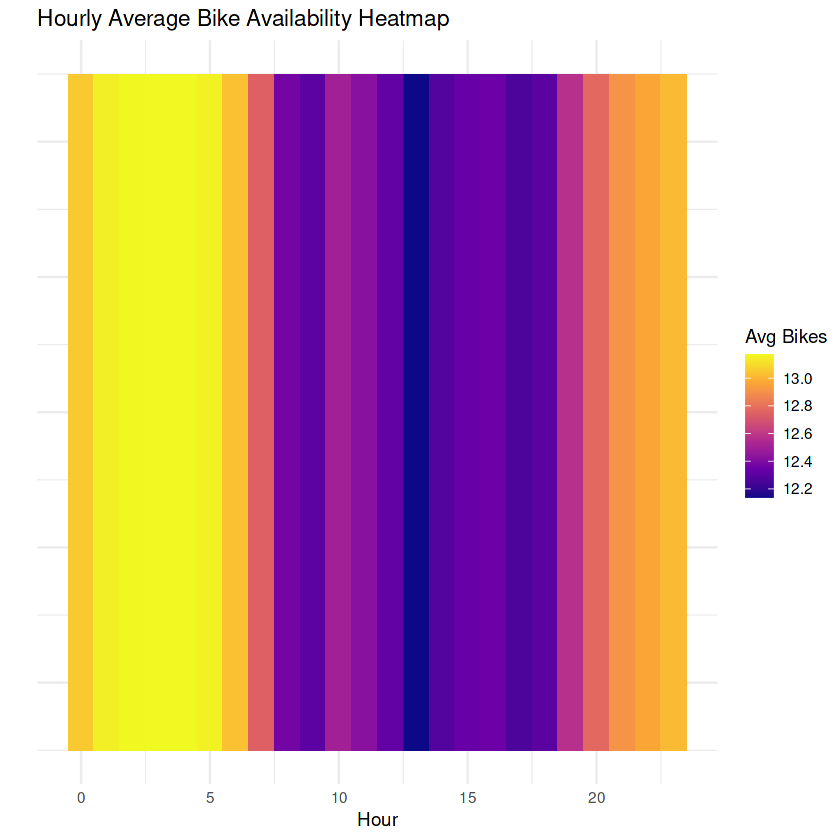

In [7]:
bikes %>%
  filter(!is.na(AVAILABLE_BIKES)) %>%
  group_by(hour) %>%
  summarise(avg_bikes = mean(AVAILABLE_BIKES, na.rm = TRUE)) %>%
  ggplot(aes(x = hour, y = 1, fill = avg_bikes)) +
  geom_tile(height = 0.5) +
  scale_fill_viridis_c(option = "plasma") +
  theme_minimal() +
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank()) +
  labs(title = "Hourly Average Bike Availability Heatmap", x = "Hour", y = "", fill = "Avg Bikes")


By weekday

Warning message:
“The dot-dot notation (`..x..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(x)` instead.”
Picking joint bandwidth of 0.828



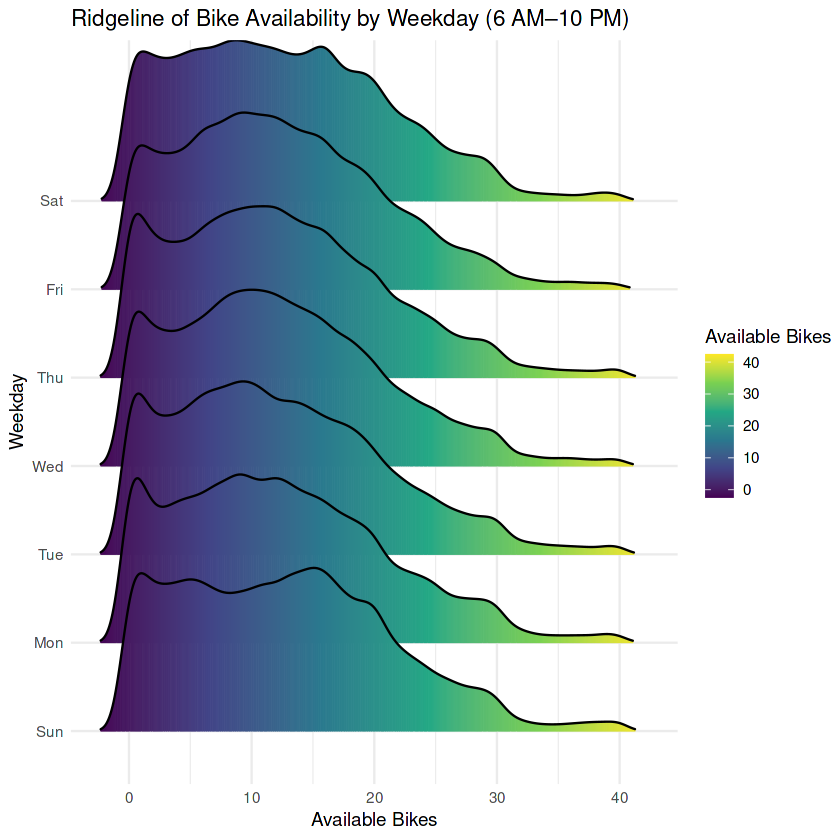

In [8]:
library(ggridges)

bikes %>%
  filter(hour >= 6 & hour <= 22) %>%
  ggplot(aes(x = AVAILABLE_BIKES, y = factor(weekday), fill = ..x..)) +
  geom_density_ridges_gradient(scale = 2, rel_min_height = 0.01) +
  scale_fill_viridis_c(name = "Available Bikes") +
  theme_minimal() +
  labs(title = "Ridgeline of Bike Availability by Weekday (6 AM–10 PM)",
       x = "Available Bikes",
       y = "Weekday")


By month

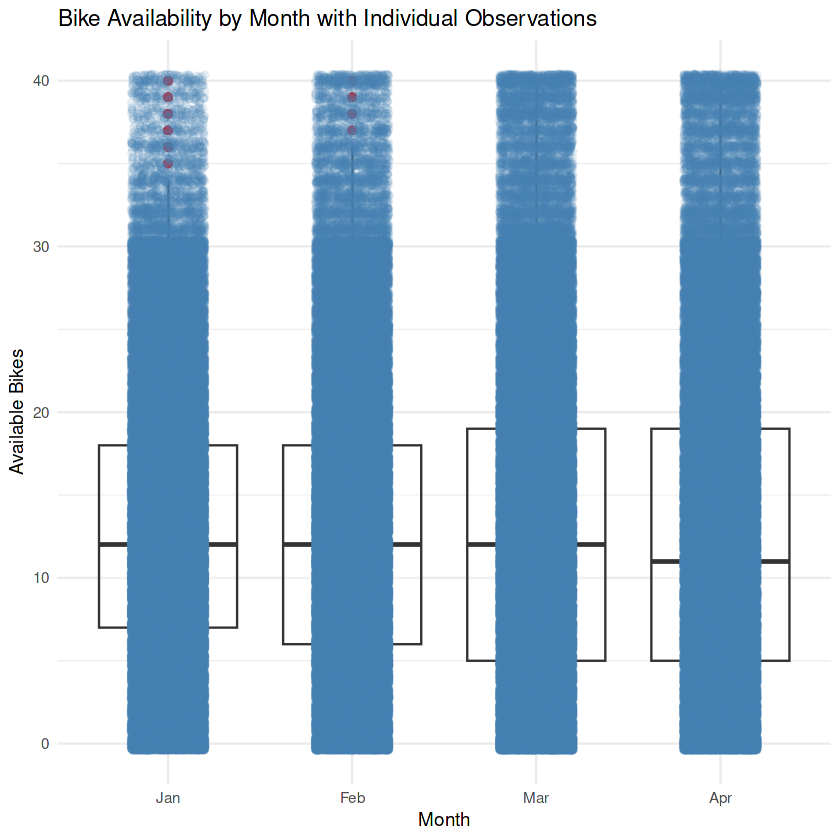

In [9]:
bikes %>%
  filter(!is.na(AVAILABLE_BIKES)) %>%
  ggplot(aes(x = factor(month), y = AVAILABLE_BIKES)) +
  geom_boxplot(outlier.color = "red", alpha = 0.3) +
  geom_jitter(width = 0.2, alpha = 0.1, color = "steelblue") +
  theme_minimal() +
  labs(title = "Bike Availability by Month with Individual Observations",
       x = "Month", y = "Available Bikes")


Heatmap: Hour vs Weekday

Loading required package: viridisLite


Attaching package: ‘viridis’


The following object is masked from ‘package:scales’:

    viridis_pal




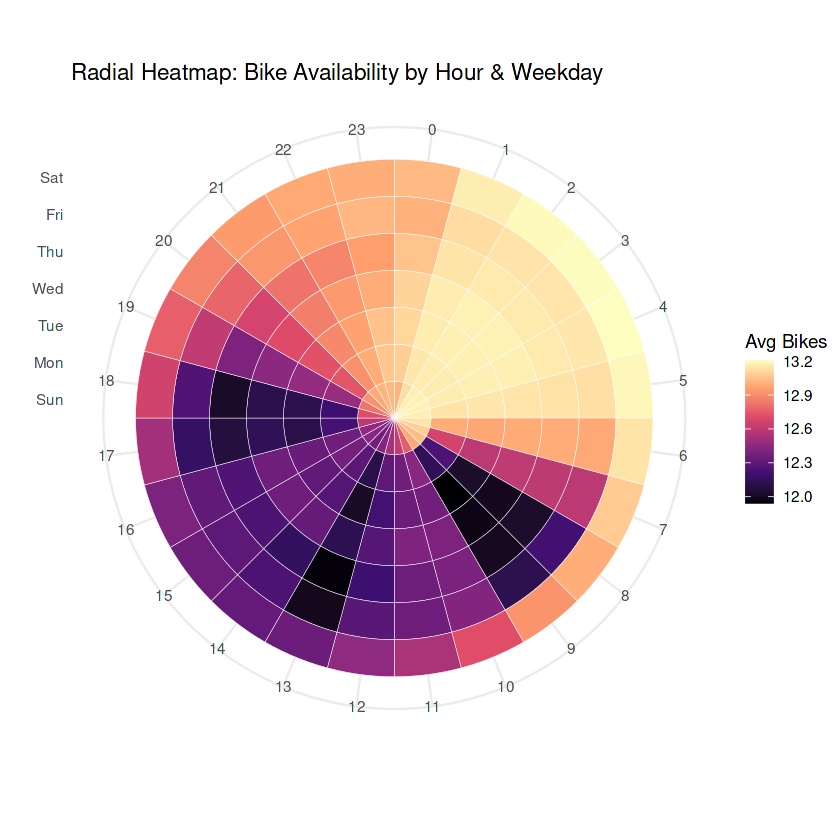

In [10]:
library(viridis)  # <-- add this

bikes %>%
  group_by(hour, weekday) %>%
  summarise(avg_bikes = mean(AVAILABLE_BIKES, na.rm = TRUE), .groups = "drop") %>%
  ggplot(aes(x = factor(hour), y = factor(weekday), fill = avg_bikes)) +
  geom_tile(color = "white") +
  coord_polar() +
  scale_fill_viridis_c(option = "magma") +  # use _c
  theme_minimal() +
  labs(title = "Radial Heatmap: Bike Availability by Hour & Weekday",
       x = "", y = "", fill = "Avg Bikes")


Top 10 Busiest Stations (Lowest Avg Bikes)

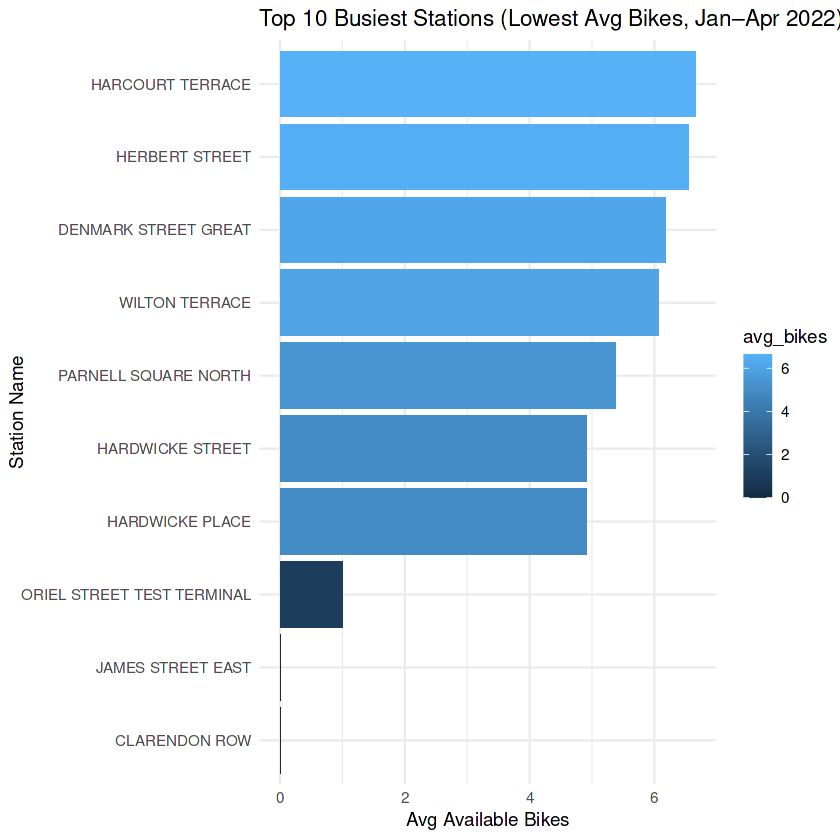

In [11]:
bikes %>%
  group_by(NAME) %>%
  summarise(avg_bikes = mean(AVAILABLE_BIKES, na.rm = TRUE)) %>%
  arrange(avg_bikes) %>%
  slice(1:10) %>%
  ggplot(aes(x = reorder(NAME, avg_bikes), y = avg_bikes, fill = avg_bikes)) +
  geom_col() +
  coord_flip() +
  theme_minimal() +
  labs(title = "Top 10 Busiest Stations (Lowest Avg Bikes, Jan–Apr 2022)",
       x = "Station Name", y = "Avg Available Bikes")



In [12]:
# Install and load leaflet
#install.packages("leaflet")

In [13]:
library(leaflet)

# Aggregate average bikes per station
station_avg <- bikes %>%
  group_by(NAME, LATITUDE, LONGITUDE) %>%
  summarise(avg_bikes = mean(AVAILABLE_BIKES, na.rm = TRUE))

# Create interactive map
leaflet(data = station_avg) %>%
  addTiles() %>%  # Add default OpenStreetMap map
  addCircleMarkers(
    ~LONGITUDE, ~LATITUDE,
    radius = ~5 + (max(avg_bikes) - avg_bikes)/2,  # bigger circles = more demand
    color = ~colorNumeric("YlOrBr", avg_bikes)(avg_bikes),
    stroke = FALSE, fillOpacity = 0.7,
    label = ~paste(NAME, "<br>Avg Bikes:", round(avg_bikes, 1))
  ) %>%
  addLegend("bottomright", pal = colorNumeric("YlOrBr", station_avg$avg_bikes),
            values = ~avg_bikes,
            title = "Average Bikes")


`summarise()` has grouped output by 'NAME', 'LATITUDE'. You can override using
the `.groups` argument.


HTML widgets cannot be represented in plain text (need html)

Validation on March (Jan–Feb trained model):
RMSE: 2.527 
MAE: 1.525 
R² (Accuracy %): 92.38 %

Forecast on April (Jan–Mar trained model):
RMSE: 2.607 
MAE: 1.554 
R² (Accuracy %): 91.91 %



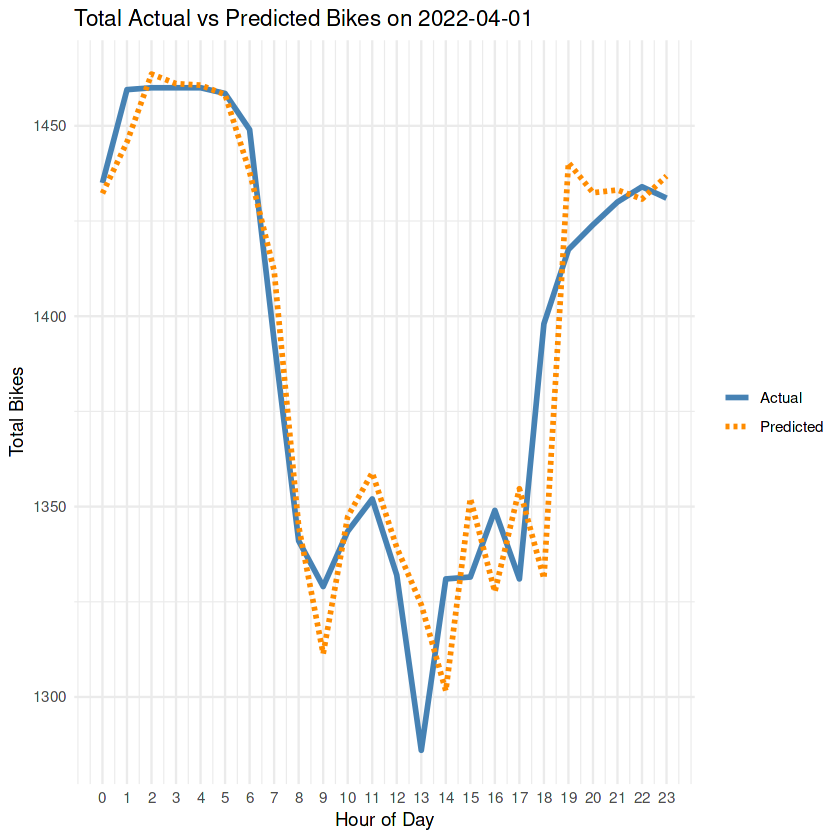

# A tibble: 24 × 2
   hour_label total_predicted
   <chr>                <dbl>
 1 01.00                1446.
 2 02.00                1464.
 3 03.00                1461.
 4 04.00                1461.
 5 05.00                1458.
 6 06.00                1438.
 7 07.00                1412.
 8 08.00                1345.
 9 09.00                1311.
10 10.00                1347.
# ℹ 14 more rows


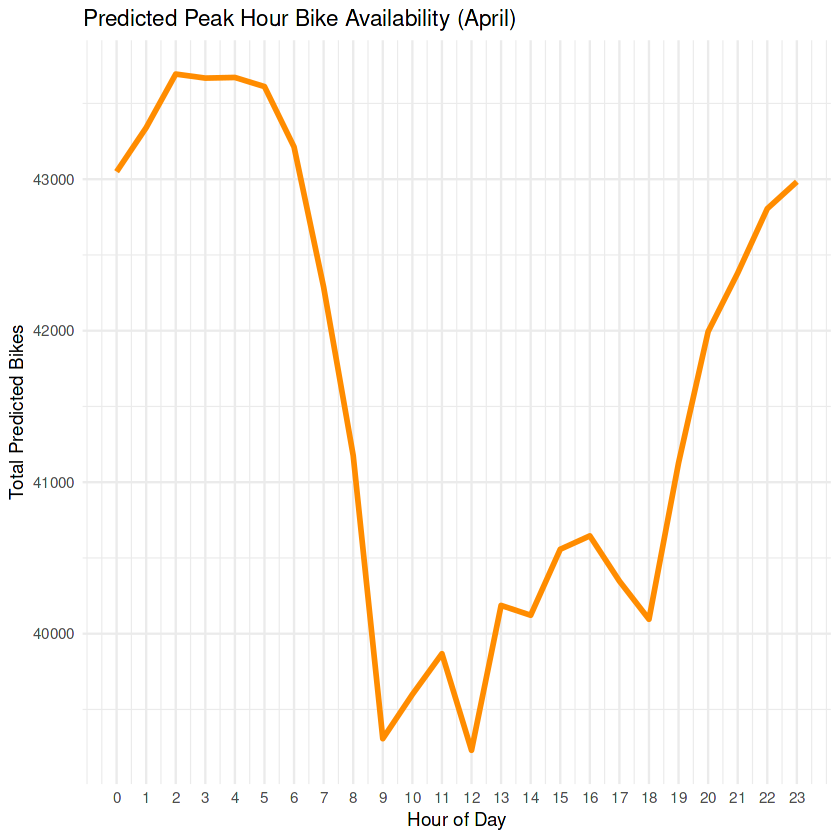

In [16]:
library(dplyr)
library(lubridate)
library(tidymodels)
library(ranger)
library(ggplot2)
library(Metrics)
library(tidyr)

# --- 0. Ensure TIME is proper datetime ---
bikes <- bikes %>%
  mutate(TIME = ymd_hms(TIME, tz="Europe/Dublin"))

# --- 1. Aggregate hourly + create lag features ---
bikes_hourly <- bikes %>%
  mutate(hour_floor = floor_date(TIME, "hour")) %>%
  group_by(`STATION ID`, hour_floor) %>%
  summarise(avg_bikes = mean(AVAILABLE_BIKES, na.rm=TRUE), .groups="drop") %>%
  arrange(`STATION ID`, hour_floor) %>%
  group_by(`STATION ID`) %>%
  mutate(
    lag_1 = lag(avg_bikes, 1),
    lag_2 = lag(avg_bikes, 2),
    lag_24 = lag(avg_bikes, 24),
    hour = hour(hour_floor),
    weekday = wday(hour_floor, label=TRUE),
    month = month(hour_floor, label=TRUE)
  ) %>%
  ungroup() %>%
  drop_na()

# --- 2. Split: Jan–Feb for training, March for testing ---
train_janfeb <- bikes_hourly %>% filter(month %in% c("Jan","Feb"))
test_march <- bikes_hourly %>% filter(month == "Mar")

# Optional: 80/20 split within Jan–Feb for internal validation
split_index <- floor(0.8 * nrow(train_janfeb))
train_data <- train_janfeb[1:split_index, ]
valid_data <- train_janfeb[(split_index+1):nrow(train_janfeb), ]

# --- 3. Train Random Forest on Jan–Feb ---
rf_model <- rand_forest(trees=500) %>%
  set_mode("regression") %>%
  set_engine("ranger") %>%
  fit(avg_bikes ~ hour + weekday + month + lag_1 + lag_2 + lag_24, data=train_data)

# --- 4. Validate on March ---
test_march$predicted <- predict(rf_model, new_data=test_march)$.pred

rmse_march <- rmse(test_march$avg_bikes, test_march$predicted)
mae_march <- mae(test_march$avg_bikes, test_march$predicted)
r2_march <- cor(test_march$avg_bikes, test_march$predicted)^2 * 100

cat("Validation on March (Jan–Feb trained model):\n")
cat("RMSE:", round(rmse_march,3), "\n")
cat("MAE:", round(mae_march,3), "\n")
cat("R² (Accuracy %):", round(r2_march,2), "%\n\n")

# --- 5. Retrain on Jan–Mar for April prediction ---
train_all <- bikes_hourly %>% filter(month %in% c("Jan","Feb","Mar"))

rf_model_final <- rand_forest(trees=500) %>%
  set_mode("regression") %>%
  set_engine("ranger") %>%
  fit(avg_bikes ~ hour + weekday + month + lag_1 + lag_2 + lag_24, data=train_all)

# --- 6. Predict April ---
test_april <- bikes_hourly %>% filter(month == "Apr")
test_april$predicted <- predict(rf_model_final, new_data=test_april)$.pred

# --- 7. Evaluate April prediction ---
rmse_april <- rmse(test_april$avg_bikes, test_april$predicted)
mae_april <- mae(test_april$avg_bikes, test_april$predicted)
r2_april <- cor(test_april$avg_bikes, test_april$predicted)^2 * 100

cat("Forecast on April (Jan–Mar trained model):\n")
cat("RMSE:", round(rmse_april,3), "\n")
cat("MAE:", round(mae_april,3), "\n")
cat("R² (Accuracy %):", round(r2_april,2), "%\n\n")

# --- 8. Plot Actual vs Predicted for April 1 (smooth lines, aggregated across stations) ---
single_day <- as.Date("2022-04-01")

april_day_total <- test_april %>%
  filter(as.Date(hour_floor) == single_day) %>%
  group_by(hour_only = hour(hour_floor)) %>%
  summarise(
    total_actual = sum(avg_bikes),
    total_predicted = sum(predicted),
    .groups = "drop"
  )

ggplot(april_day_total, aes(x = hour_only)) +
  geom_line(aes(y = total_actual, color = "Actual"), linewidth = 1.2) +
  geom_line(aes(y = total_predicted, color = "Predicted"), linewidth = 1.2, linetype = "dashed") +
  scale_x_continuous(breaks = 0:23) +
  theme_minimal() +
  labs(
    title = paste("Total Actual vs Predicted Bikes on", single_day),
    x = "Hour of Day",
    y = "Total Bikes"
  ) +
  scale_color_manual(values = c("Actual" = "steelblue", "Predicted" = "darkorange")) +
  theme(legend.title = element_blank())

# --- 9. Peak hours chart (predicted only, line chart) ---
peak_time <- test_april %>%
  mutate(hour_only = hour(hour_floor)) %>%
  group_by(hour_only) %>%
  summarise(
    total_predicted = sum(predicted),  # total across all stations
    .groups = "drop"
  )

# --- Plot line chart only ---
ggplot(peak_time, aes(x = hour_only, y = total_predicted)) +
  geom_line(color = "darkorange", linewidth = 1.2) +
  scale_x_continuous(breaks = 0:23) +
  theme_minimal() +
  labs(
    title = "Predicted Peak Hour Bike Availability (April)",
    x = "Hour of Day",
    y = "Total Predicted Bikes"
  )

# --- Total predicted bikes per hour for April 1 ---
single_day <- as.Date("2022-04-01")

predicted_april1 <- test_april %>%
  filter(as.Date(hour_floor) == single_day) %>%
  mutate(hour_only = hour(hour_floor)) %>%
  group_by(hour_only) %>%
  summarise(
    total_predicted = sum(predicted),
    .groups = "drop"
  ) %>%
  arrange(hour_only) %>%  # sort numerically first
  mutate(
    hour_label = ifelse(hour_only == 0, "24.00",
                        sprintf("%02d.00", hour_only))
  ) %>%
  select(hour_label, total_predicted)
print(predicted_april1, n = 24)






In [22]:
library(parsnip)

# --- Convert month to numeric for LR ---
train_all_lr <- train_all %>%
  mutate(month = as.numeric(month))  # Jan=1, Feb=2, Mar=3

test_april_lr <- test_april %>%
  mutate(month = as.numeric(month))  # Apr=4

# --- Train LR on Jan–Mar (numeric month) ---
lr_model <- linear_reg() %>%
  set_mode("regression") %>%
  set_engine("lm") %>%
  fit(avg_bikes ~ hour + weekday + month + lag_1 + lag_2 + lag_24,
      data = train_all_lr)

# --- Predict on April ---
test_april_lr$predicted_lr <- predict(lr_model, new_data = test_april_lr)$.pred

# --- Aggregate total per hour for April 1 ---
single_day <- as.Date("2022-04-01")
april1_lr <- test_april_lr %>%
  filter(as.Date(hour_floor) == single_day) %>%
  group_by(hour_only = hour(hour_floor)) %>%
  summarise(
    total_actual = sum(avg_bikes),
    total_predicted_lr = sum(predicted_lr),
    .groups = "drop"
  ) %>%
  mutate(hour_label = ifelse(hour_only==0,"24.00", sprintf("%02d.00", hour_only))) %>%
  select(hour_label, total_actual, total_predicted_lr)

print(april1_lr)


# A tibble: 24 × 3
   hour_label total_actual total_predicted_lr
   <chr>             <dbl>              <dbl>
 1 24.00             1435               1425.
 2 01.00             1460.              1435.
 3 02.00             1460               1457.
 4 03.00             1460               1454.
 5 04.00             1460               1454.
 6 05.00             1458.              1455.
 7 06.00             1449               1452.
 8 07.00             1394.              1440.
 9 08.00             1341               1377.
10 09.00             1329               1328.
# ℹ 14 more rows


In [23]:
rmse_lr <- rmse(april1_lr$total_actual, april1_lr$total_predicted_lr)
mae_lr <- mae(april1_lr$total_actual, april1_lr$total_predicted_lr)
r2_lr <- cor(april1_lr$total_actual, april1_lr$total_predicted_lr)^2 * 100

cat("Linear Regression April 1 Performance:\n")
cat("RMSE:", round(rmse_lr,3), "\n")
cat("MAE:", round(mae_lr,3), "\n")
cat("R² (Accuracy %):", round(r2_lr,2), "%\n")


Linear Regression April 1 Performance:
RMSE: 24.665 
MAE: 16.751 
R² (Accuracy %): 80.45 %
